In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

print("Bugün ne yapacağız:")
print("1. GAN mimarisini anla")
print("2. Generator — rastgele gürültüden görüntü üret")
print("3. Discriminator — gerçek/sahte ayırt et")
print("4. İkisini birlikte eğit")
print("5. Eğitim boyunca üretilen görüntüleri izle")
print("\nHedef: MNIST rakamlarını sıfırdan üretmek!")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("\nPyTorch:", torch.__version__)

Bugün ne yapacağız:
1. GAN mimarisini anla
2. Generator — rastgele gürültüden görüntü üret
3. Discriminator — gerçek/sahte ayırt et
4. İkisini birlikte eğit
5. Eğitim boyunca üretilen görüntüleri izle

Hedef: MNIST rakamlarını sıfırdan üretmek!

PyTorch: 2.10.0+cpu


Veri seti: 60000 görüntü
Batch sayısı: 469


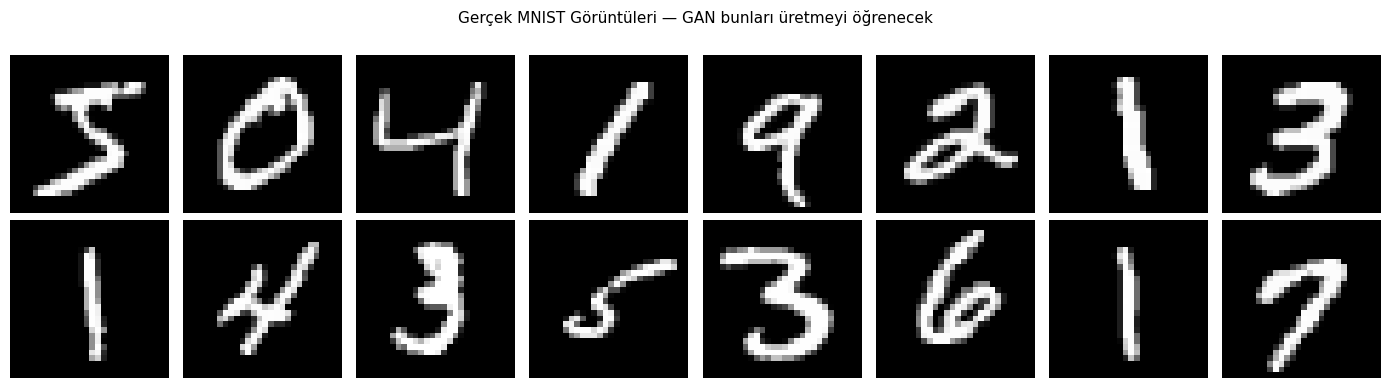

In [3]:
# Veri
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # -1 ile 1 arası
])

dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

print(f"Veri seti: {len(dataset)} görüntü")
print(f"Batch sayısı: {len(loader)}")

# Birkaç gerçek görüntü göster
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    img, _ = dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle("Gerçek MNIST Görüntüleri — GAN bunları üretmeyi öğrenecek", fontsize=11)
plt.tight_layout()
plt.show()

In [4]:
# Gürültü boyutu — Generator'ın girdi vektörü
LATENT_DIM = 100

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # 100 → 256
            nn.Linear(LATENT_DIM, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),

            # 256 → 512
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),

            # 512 → 1024
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),

            # 1024 → 784 (28x28)
            nn.Linear(1024, 784),
            nn.Tanh()  # -1 ile 1 arası çıktı
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(-1, 1, 28, 28)  # Görüntü şekline getir

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # 784 → 512
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # 512 → 256
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # 256 → 1 (gerçek mi sahte mi?)
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(-1, 784)
        return self.model(img_flat)

# Modelleri oluştur
G = Generator()
D = Discriminator()

print("Generator:")
print(f"  Parametre: {sum(p.numel() for p in G.parameters()):,}")
print("\nDiscriminator:")
print(f"  Parametre: {sum(p.numel() for p in D.parameters()):,}")

# Test et
z = torch.randn(4, LATENT_DIM)
fake_imgs = G(z)
d_out = D(fake_imgs)
print(f"\nGenerator çıktı shape: {fake_imgs.shape}")
print(f"Discriminator çıktı: {d_out.detach().numpy().flatten().round(3)}")
print("(0 = sahte, 1 = gerçek — henüz eğitilmedi)")

Generator:
  Parametre: 1,489,936

Discriminator:
  Parametre: 533,505

Generator çıktı shape: torch.Size([4, 1, 28, 28])
Discriminator çıktı: [0.509 0.527 0.526 0.52 ]
(0 = sahte, 1 = gerçek — henüz eğitilmedi)


In [5]:
# Optimizer ve Loss
criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Eğitim boyunca üretilen görüntüleri kaydet
fixed_noise = torch.randn(16, LATENT_DIM)  # Hep aynı gürültü — ilerlemeyi görmek için
generated_images = []

g_losses, d_losses = [], []

print("GAN eğitimi başlıyor...")
print("Her 5 epoch'ta üretilen görüntüler kaydedilecek\n")

for epoch in range(30):
    g_loss_epoch, d_loss_epoch = 0, 0

    for real_imgs, _ in loader:
        batch_size = real_imgs.size(0)

        # Gerçek ve sahte etiketler
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # === Discriminator Eğitimi ===
        optimizer_D.zero_grad()

        # Gerçek görüntüleri değerlendir
        real_loss = criterion(D(real_imgs), real_labels)

        # Sahte görüntüler üret ve değerlendir
        z = torch.randn(batch_size, LATENT_DIM)
        fake_imgs = G(z).detach()  # G'yi güncelleme!
        fake_loss = criterion(D(fake_imgs), fake_labels)

        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # === Generator Eğitimi ===
        optimizer_G.zero_grad()

        z = torch.randn(batch_size, LATENT_DIM)
        fake_imgs = G(z)
        # Generator, D'yi kandırmaya çalışır — etiket 1 (gerçek) hedefler
        g_loss = criterion(D(fake_imgs), real_labels)
        g_loss.backward()
        optimizer_G.step()

        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

    g_losses.append(g_loss_epoch / len(loader))
    d_losses.append(d_loss_epoch / len(loader))

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/30 | G Loss: {g_losses[-1]:.4f} | D Loss: {d_losses[-1]:.4f}")

        # Üretilen görüntüleri kaydet
        with torch.no_grad():
            imgs = G(fixed_noise).detach()
        generated_images.append(imgs)

print("\nEğitim tamamlandı!")

GAN eğitimi başlıyor...
Her 5 epoch'ta üretilen görüntüler kaydedilecek

Epoch  5/30 | G Loss: 0.8255 | D Loss: 0.6437
Epoch 10/30 | G Loss: 0.7520 | D Loss: 0.6741
Epoch 15/30 | G Loss: 0.7361 | D Loss: 0.6815
Epoch 20/30 | G Loss: 0.7326 | D Loss: 0.6833
Epoch 25/30 | G Loss: 0.7310 | D Loss: 0.6832
Epoch 30/30 | G Loss: 0.7290 | D Loss: 0.6849

Eğitim tamamlandı!


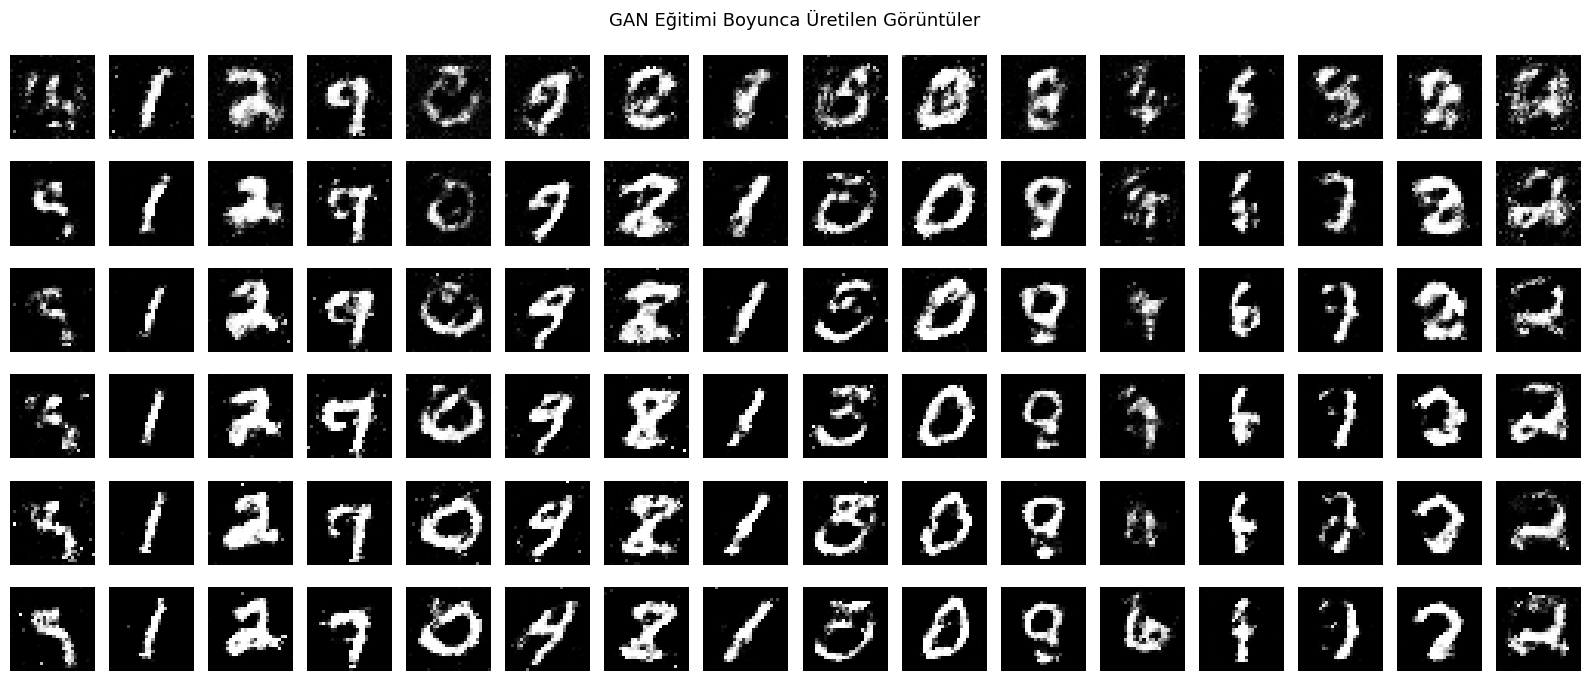

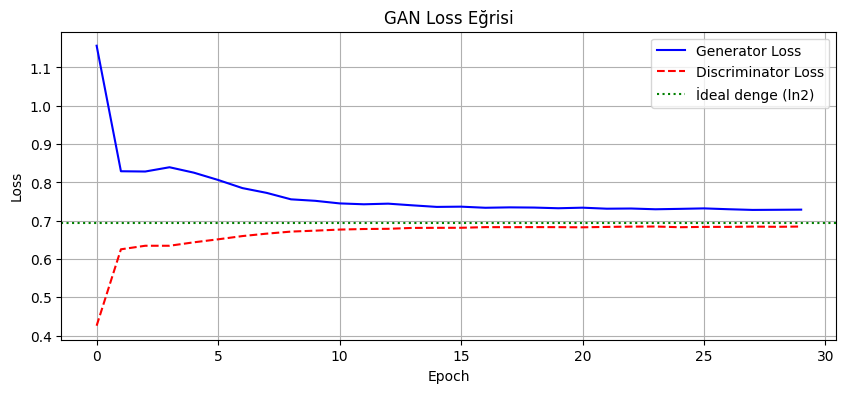

In [6]:
fig, axes = plt.subplots(6, 16, figsize=(16, 7))

for row, imgs in enumerate(generated_images):
    for col in range(16):
        ax = axes[row, col]
        ax.imshow(imgs[col].squeeze().numpy(), cmap='gray')
        ax.axis('off')
    axes[row, 0].set_ylabel(f'Epoch\n{(row+1)*5}', fontsize=8, rotation=0, labelpad=35)

plt.suptitle("GAN Eğitimi Boyunca Üretilen Görüntüler", fontsize=13)
plt.tight_layout()
plt.show()

# Loss grafiği
plt.figure(figsize=(10, 4))
plt.plot(g_losses, label='Generator Loss', color='blue')
plt.plot(d_losses, label='Discriminator Loss', color='red', linestyle='--')
plt.axhline(y=0.693, color='green', linestyle=':', label='İdeal denge (ln2)')
plt.title("GAN Loss Eğrisi")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

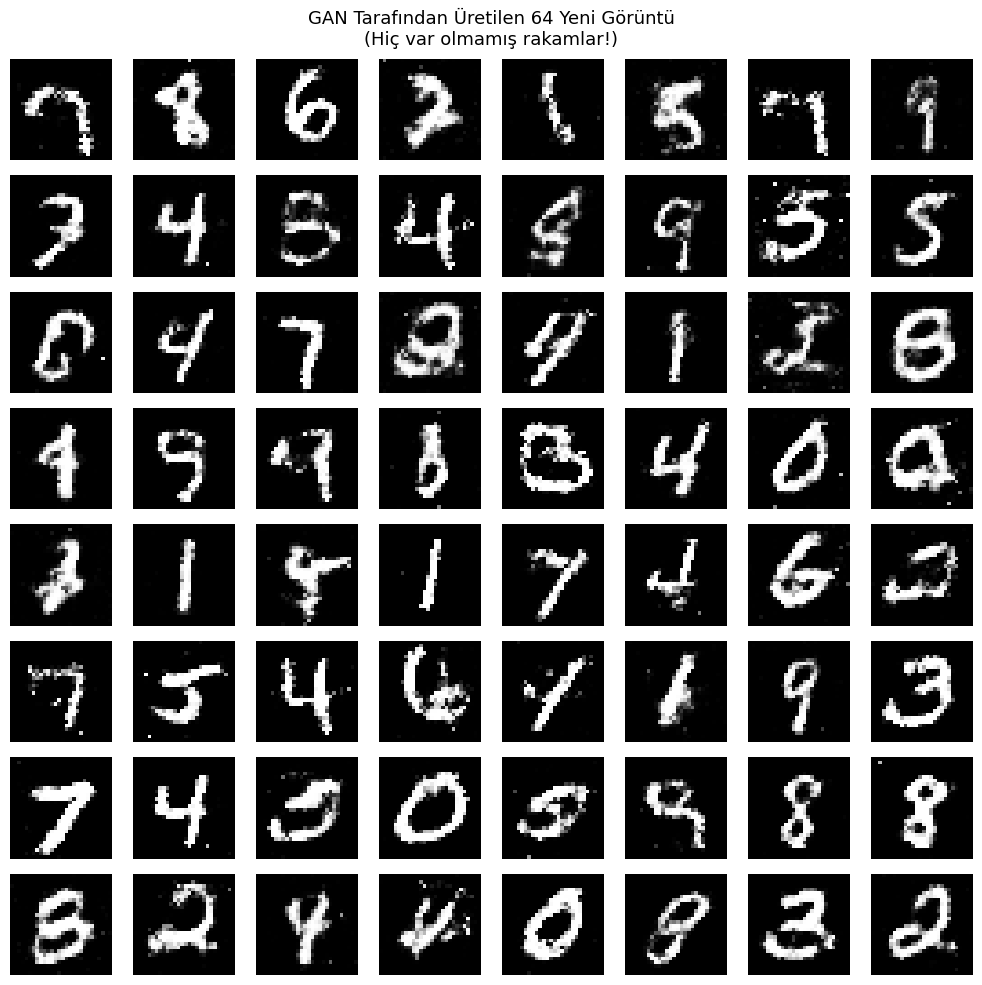

✅ Generator kaydedildi: gan_generator.pth


In [7]:
# Tamamen yeni rastgele görüntüler üret
G.eval()
with torch.no_grad():
    z = torch.randn(64, LATENT_DIM)
    fake_imgs = G(z)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(fake_imgs[i].squeeze().numpy(), cmap='gray')
    ax.axis('off')

plt.suptitle("GAN Tarafından Üretilen 64 Yeni Görüntü\n(Hiç var olmamış rakamlar!)", fontsize=13)
plt.tight_layout()
plt.show()

# Modeli kaydet
torch.save(G.state_dict(), 'gan_generator.pth')
print("✅ Generator kaydedildi: gan_generator.pth")